In [1]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import fetch_california_housing  
import warnings

warnings.filterwarnings('ignore') 

In [2]:
data = fetch_california_housing()

In [3]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
X = pd.DataFrame(data.data , columns=data.feature_names)
y = pd.Series(data.target)

In [21]:
X.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


In [6]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
dtype: float64

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2)

In [8]:
gradientRegressor = GradientBoostingRegressor(max_depth=2, n_estimators=3 , learning_rate=1)
gradientRegressor

GradientBoostingRegressor(learning_rate=1, max_depth=2, n_estimators=3)

In [9]:
model = gradientRegressor.fit(X_train , y_train)
model

GradientBoostingRegressor(learning_rate=1, max_depth=2, n_estimators=3)

In [10]:
y_pred = model.predict(X_test)
y_pred

array([2.06164622, 1.18309607, 1.31419956, ..., 1.31419956, 1.64447749,
       2.06164622])

In [11]:
from sklearn.metrics import r2_score
r2 = r2_score(y_pred , y_test)
r2

0.31292380721618107

In [12]:
import matplotlib.pyplot as plt
feature_imp = model.feature_importances_

AttributeError: feature_name

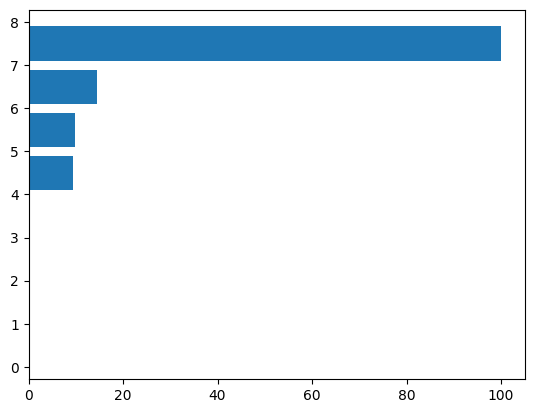

In [13]:
feature_imp = 100.0 * (feature_imp / feature_imp.max())
sorted_idx = np.argsort(feature_imp)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.barh(pos,feature_imp[sorted_idx] , align = 'center')
plt.yticks(pos,data.feature_name[sorted_idx])
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

lr = {
    'learning_rate': [0.15, 0.1, 0.05],  
    'n_estimators': [100, 150, 200, 250] 
}
print(lr)

# Initialize GridSearchCV
tuning = GridSearchCV(
    estimator=GradientBoostingRegressor(), 
    param_grid=lr, 
    scoring='r2', 
    cv=5,  
    n_jobs=-1 
)
print(tuning)

# Fit the model
tuning.fit(X_train, y_train)

{'learning_rate': [0.15, 0.1, 0.05], 'n_estimators': [100, 150, 200, 250]}
GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.15, 0.1, 0.05],
                         'n_estimators': [100, 150, 200, 250]},
             scoring='r2')


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.15, 0.1, 0.05],
                         'n_estimators': [100, 150, 200, 250]},
             scoring='r2')

In [19]:
print("Best Parameters:", tuning.best_params_)
print("Best R2 Score:", tuning.best_score_)

Best Parameters: {'learning_rate': 0.15, 'n_estimators': 250}
Best R2 Score: 0.8194352669248147
